In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaincc, gamma
from utils import uniform, choice

plt.rcParams["figure.dpi"] = 300

$$p_\xi(x) = \frac{3e}{1+3e}\underbrace{x^{-2}}_{p_1(x)} + \frac{1}{1 + 3e}\underbrace{3ex^2e^{-x^3}}_{p_2(x)}$$
$$\xi_1 = \frac{1}{1-\alpha} = \frac{1}{\alpha}$$
$$\xi_2 = \sqrt[3]{1 - \ln{(\alpha)}}$$

In [2]:
p2 = 1 / (1 + 3 * np.exp(1))
xi = [
    lambda x: 1 / x,
    lambda x: np.cbrt(1 - np.log(x))
]

def pdf(size=None):
    r1 = uniform(size)
    is_second = (r1 < p2)
    r2 = uniform(size)

    r2[is_second] = xi[1](r2[is_second])
    r2[~is_second] = xi[0](r2[~is_second])

    return r2


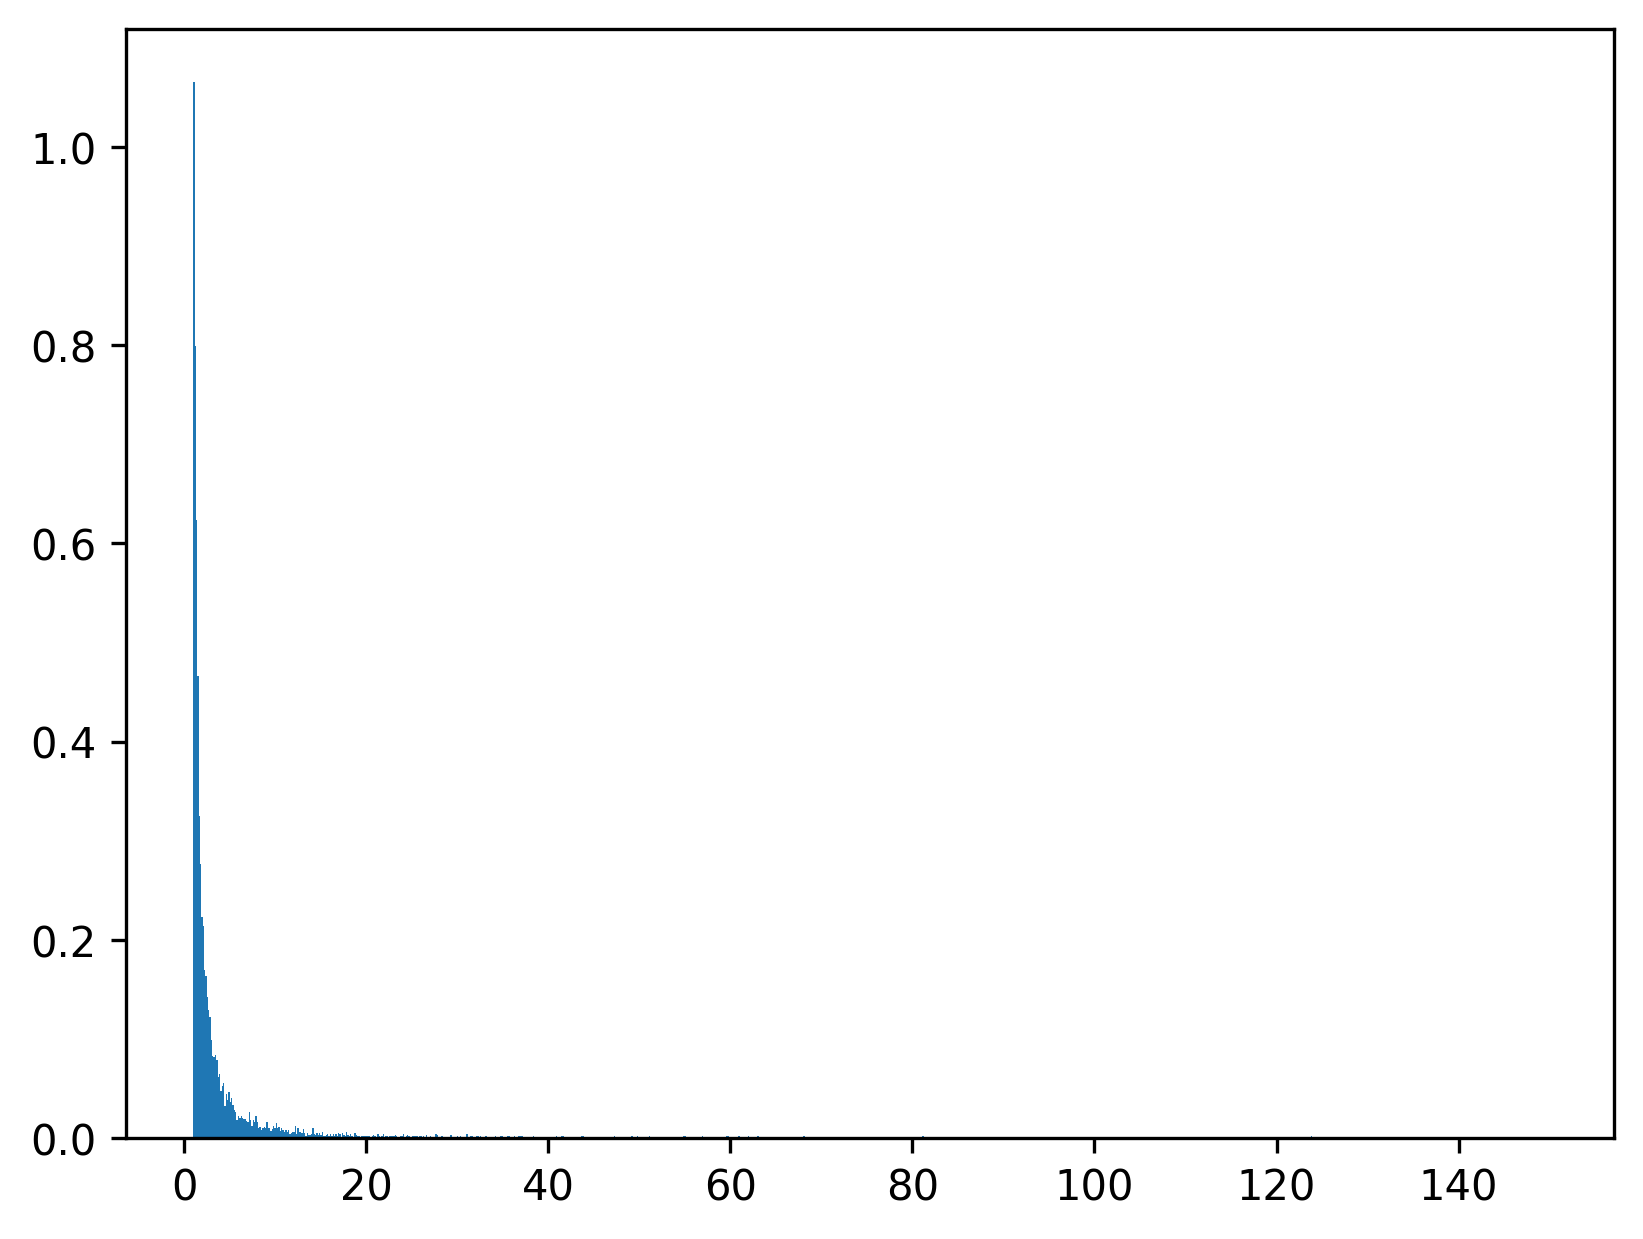

In [3]:
res = pdf(10_000)

plt.hist(res[res < 150], bins=1000, density=True)
None

In [20]:
def mean(size, order = 1):
    return np.mean(pdf(size) ** order)

In [22]:
m1 = mean(100_000)
m2 = mean(100_000, 2)
m1, m2

(np.float64(11.804888417355551), np.float64(67070.56269757757))

In [16]:
def norm(a=0, std=1, n=12, size=None):
    shape = n
    if size is not None:
        shape = (size, n)
    U = np.sum(uniform(shape), axis=1)
    zeta = np.sqrt(12 / n) * (U - n / 2)

    return a + std * zeta

In [15]:
a = uniform((2, 3))
np.sum(a, axis=1), a

(array([1.21452855, 1.05296415]),
 array([[0.38763357, 0.28382707, 0.54306791],
        [0.49118935, 0.17639519, 0.38537962]]))

In [45]:
def hist(x, h):
    N = len(x)
    half_h = h / 2
    l, r = x.min(), x.max()
    start = l - half_h
    bins = np.arange(start, r + h + half_h, h)
    counts = np.zeros(len(bins) - 1)

    bin_nums = ((x - start) / h).astype(int)
    for n in bin_nums:
        counts[n] += 1
    return bins, counts / N

def in_range(center, height, low, up):
    mask = (center <= up) & (center >= low)

    return height[mask].sum() / height.sum()

In [21]:
hist(uniform(10_000), 0.01)[1].sum()

np.float64(1.0)

In [12]:
np.mean(norm(size=10_000))

np.float64(4997.0125737224)

In [66]:
def plot_hist_sig(a, std, h, size=10_000):
    res = hist(norm(a, std, size=size), h)
    centers = (res[0][:-1] + res[0][1:]) / 2
    print(*res)

    plt.figure(figsize=(12, 7))
    plt.bar(centers, res[1], width=h, alpha=0.2, color="gray", label="Outliers")
    ratios = []
    for i in range(1, 4):
        low = a - i * std
        up = a + i * std

        in_rng_perc = in_range(centers, res[1], low, up) * 100
        ratios.append(in_rng_perc)

        mask = (centers >= low) & (centers <= up)
        plt.bar(
            centers[mask],
            res[1][mask],
            width=h,
            alpha=0.8 - (i - 1) * 0.2,
            color="forestgreen",
            label=rf"{i}$\sigma\sim$ ({in_rng_perc:.2f}%)",
        )

    plt.axvline(a - 3 * std, color="darkgreen", linestyle=":", alpha=0.5)
    plt.axvline(a + 3 * std, color="darkgreen", linestyle=":", alpha=0.5)
    plt.axvline(a, color="black", linestyle="-", lw=1.5)

    max_y = max(res[1])
    plt.text(
        a, max_y * 0.2, f"{ratios[0]:.2f}%", ha="center", fontweight="bold", color="white"
    )
    plt.text(
        a + 1.5 * std, max_y * 0.1, f"{ratios[1]:.2f}%", ha="center", fontweight="bold"
    )
    plt.text(
        a + 2.5 * std, max_y * 0.02, f"{ratios[2]:.2f}%", ha="center", fontweight="bold"
    )

    plt.grid(axis="y", alpha=0.3)
    plt.xticks([a - 3 * std, a - 2 * std, a - std, a, a + std, a + 2 * std, a + 3 * std])
    plt.legend()
    plt.tight_layout()
    plt.show()

[-9.51505592 -8.71505592 -7.91505592 -7.11505592 -6.31505592 -5.51505592
 -4.71505592 -3.91505592 -3.11505592 -2.31505592 -1.51505592 -0.71505592
  0.08494408  0.88494408  1.68494408  2.48494408  3.28494408  4.08494408
  4.88494408  5.68494408  6.48494408  7.28494408  8.08494408  8.88494408
  9.68494408 10.48494408 11.28494408 12.08494408 12.88494408 13.68494408
 14.48494408] [2.000e-04 2.000e-04 5.000e-04 1.500e-03 3.900e-03 6.800e-03 1.400e-02
 2.460e-02 3.210e-02 4.440e-02 6.060e-02 7.450e-02 9.090e-02 1.055e-01
 1.025e-01 9.850e-02 8.820e-02 8.070e-02 5.770e-02 4.410e-02 2.830e-02
 1.860e-02 1.050e-02 6.100e-03 3.300e-03 1.200e-03 2.000e-04 2.000e-04
 1.000e-04 1.000e-04]


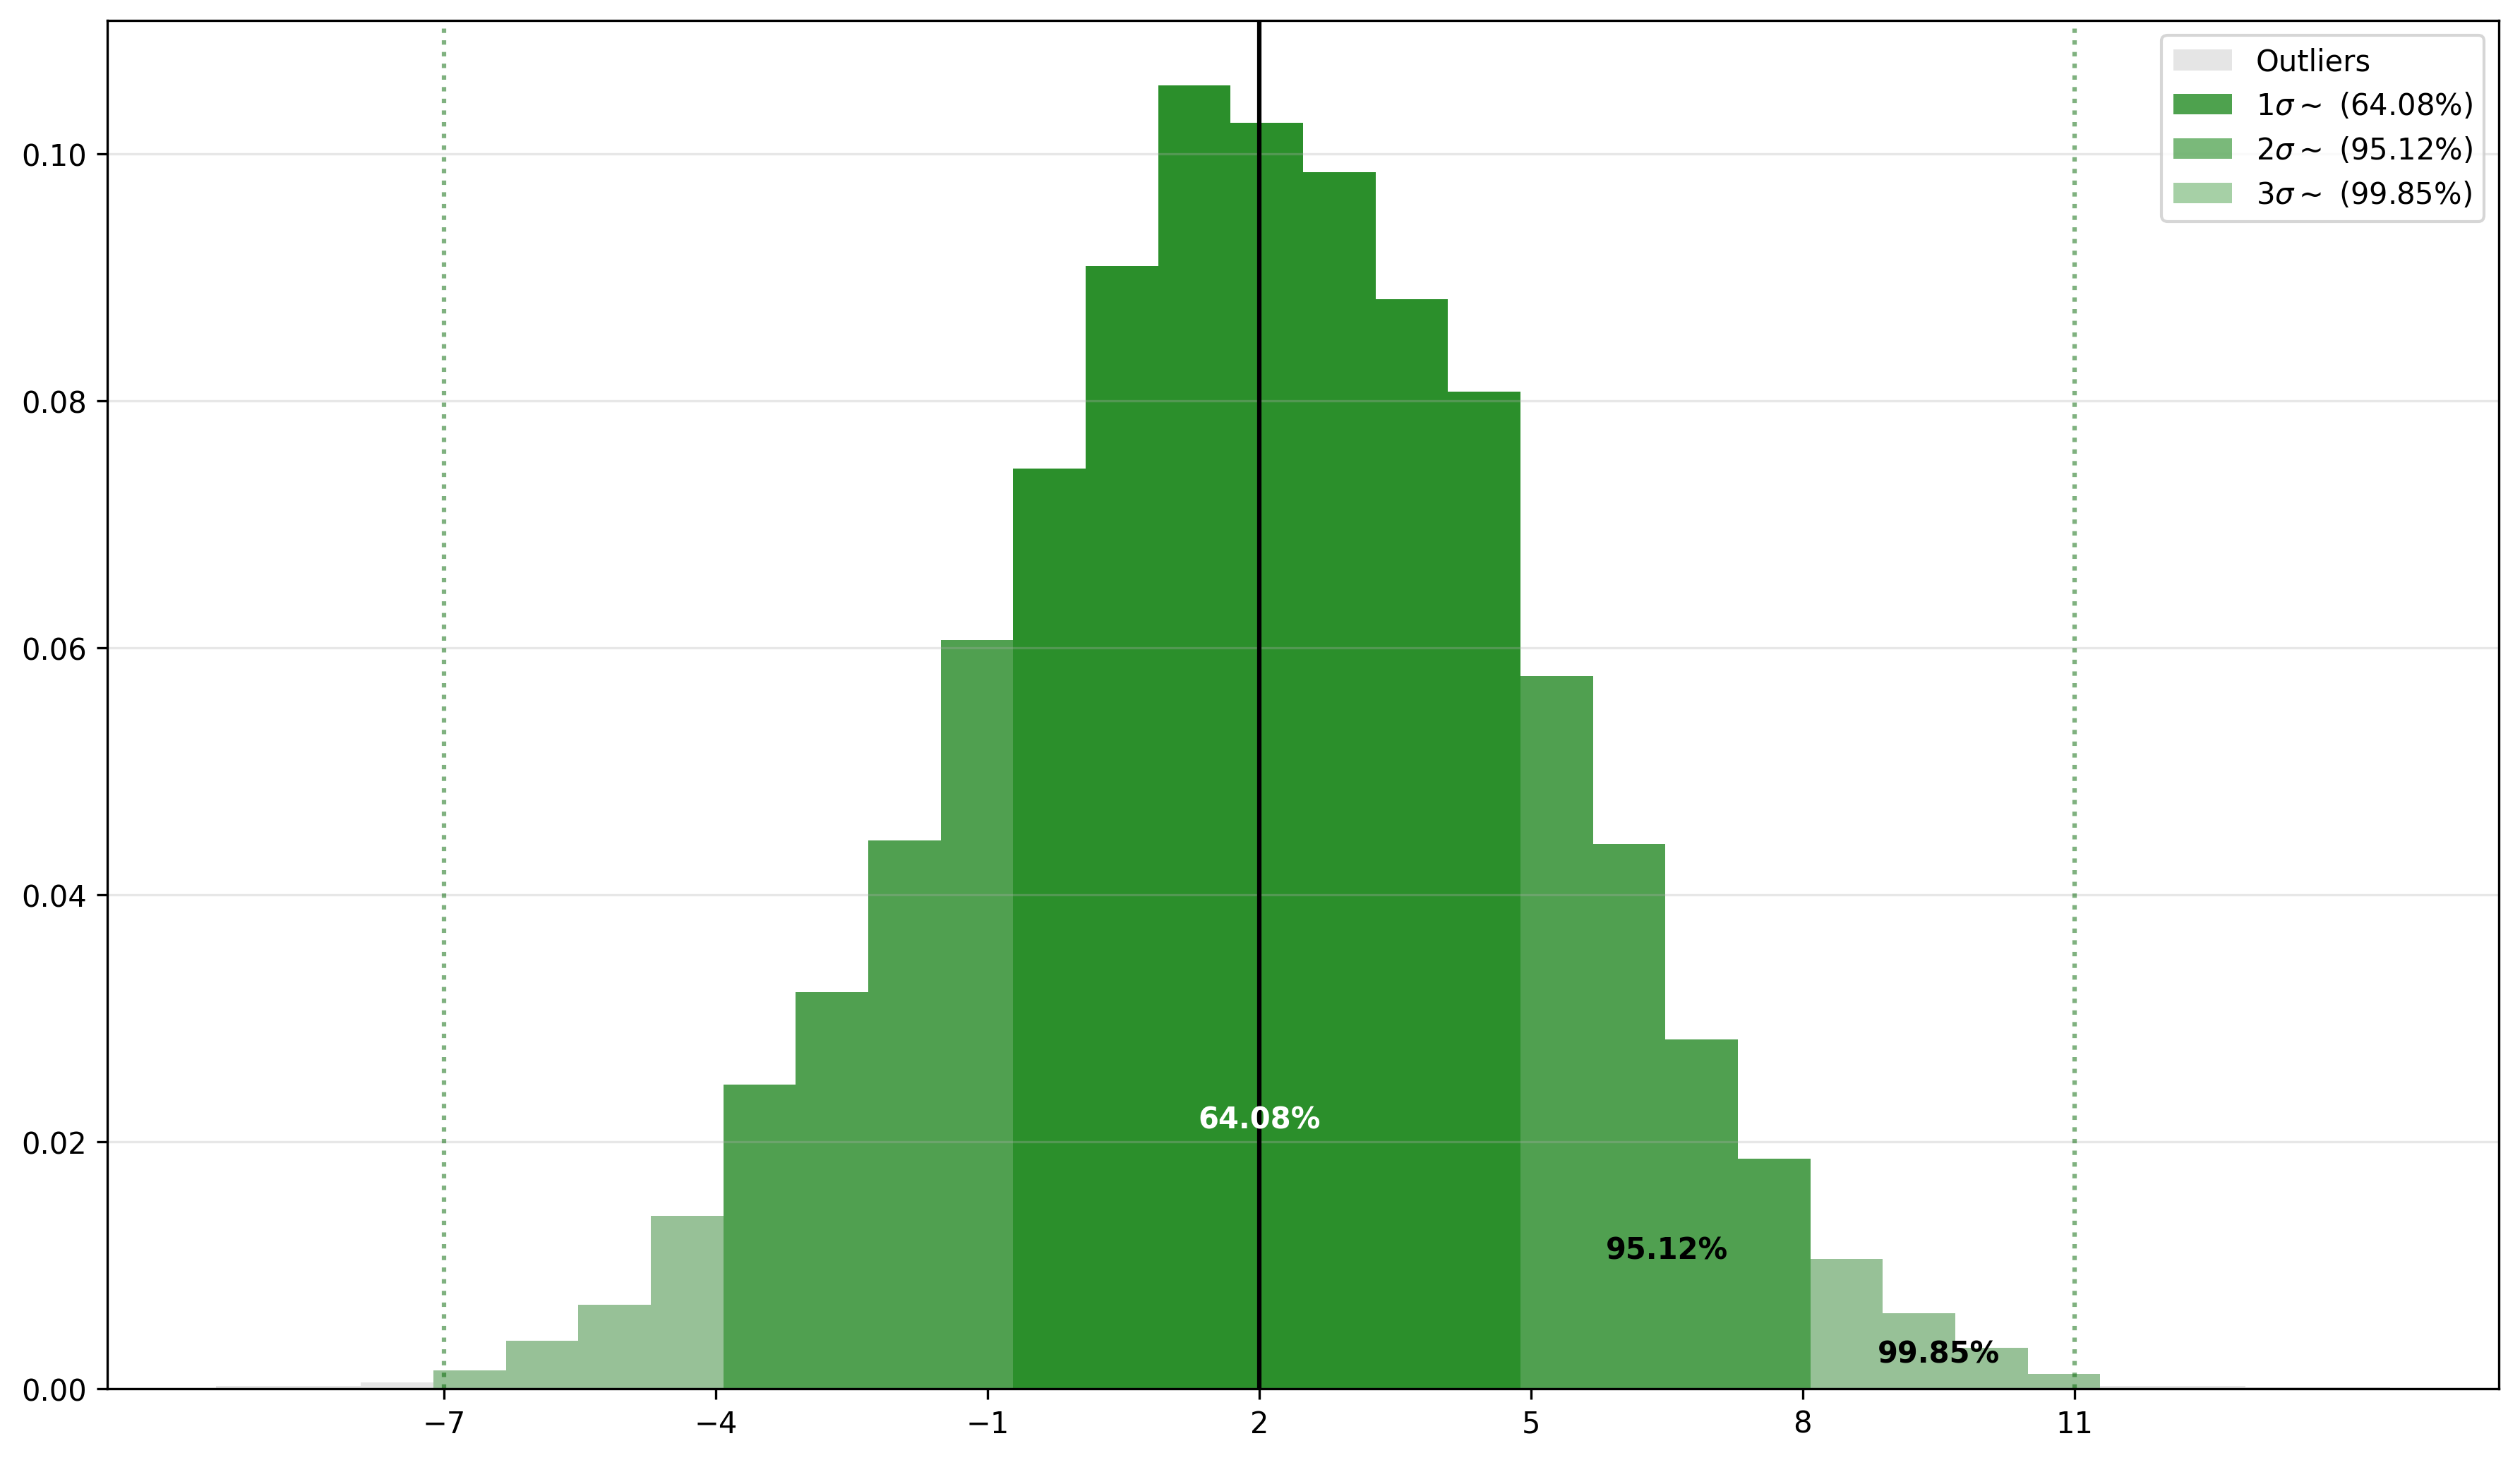

[-8.83362688 -8.75362688 -8.67362688 -8.59362688 -8.51362688 -8.43362688
 -8.35362688 -8.27362688 -8.19362688 -8.11362688 -8.03362688 -7.95362688
 -7.87362688 -7.79362688 -7.71362688 -7.63362688 -7.55362688 -7.47362688
 -7.39362688 -7.31362688 -7.23362688 -7.15362688 -7.07362688 -6.99362688
 -6.91362688 -6.83362688 -6.75362688 -6.67362688 -6.59362688 -6.51362688
 -6.43362688 -6.35362688 -6.27362688 -6.19362688 -6.11362688 -6.03362688
 -5.95362688 -5.87362688 -5.79362688 -5.71362688 -5.63362688 -5.55362688
 -5.47362688 -5.39362688 -5.31362688 -5.23362688 -5.15362688 -5.07362688
 -4.99362688 -4.91362688 -4.83362688 -4.75362688 -4.67362688 -4.59362688
 -4.51362688 -4.43362688 -4.35362688 -4.27362688 -4.19362688 -4.11362688
 -4.03362688 -3.95362688 -3.87362688 -3.79362688 -3.71362688 -3.63362688
 -3.55362688 -3.47362688 -3.39362688 -3.31362688 -3.23362688 -3.15362688
 -3.07362688 -2.99362688 -2.91362688 -2.83362688 -2.75362688 -2.67362688
 -2.59362688 -2.51362688 -2.43362688 -2.35362688 -2

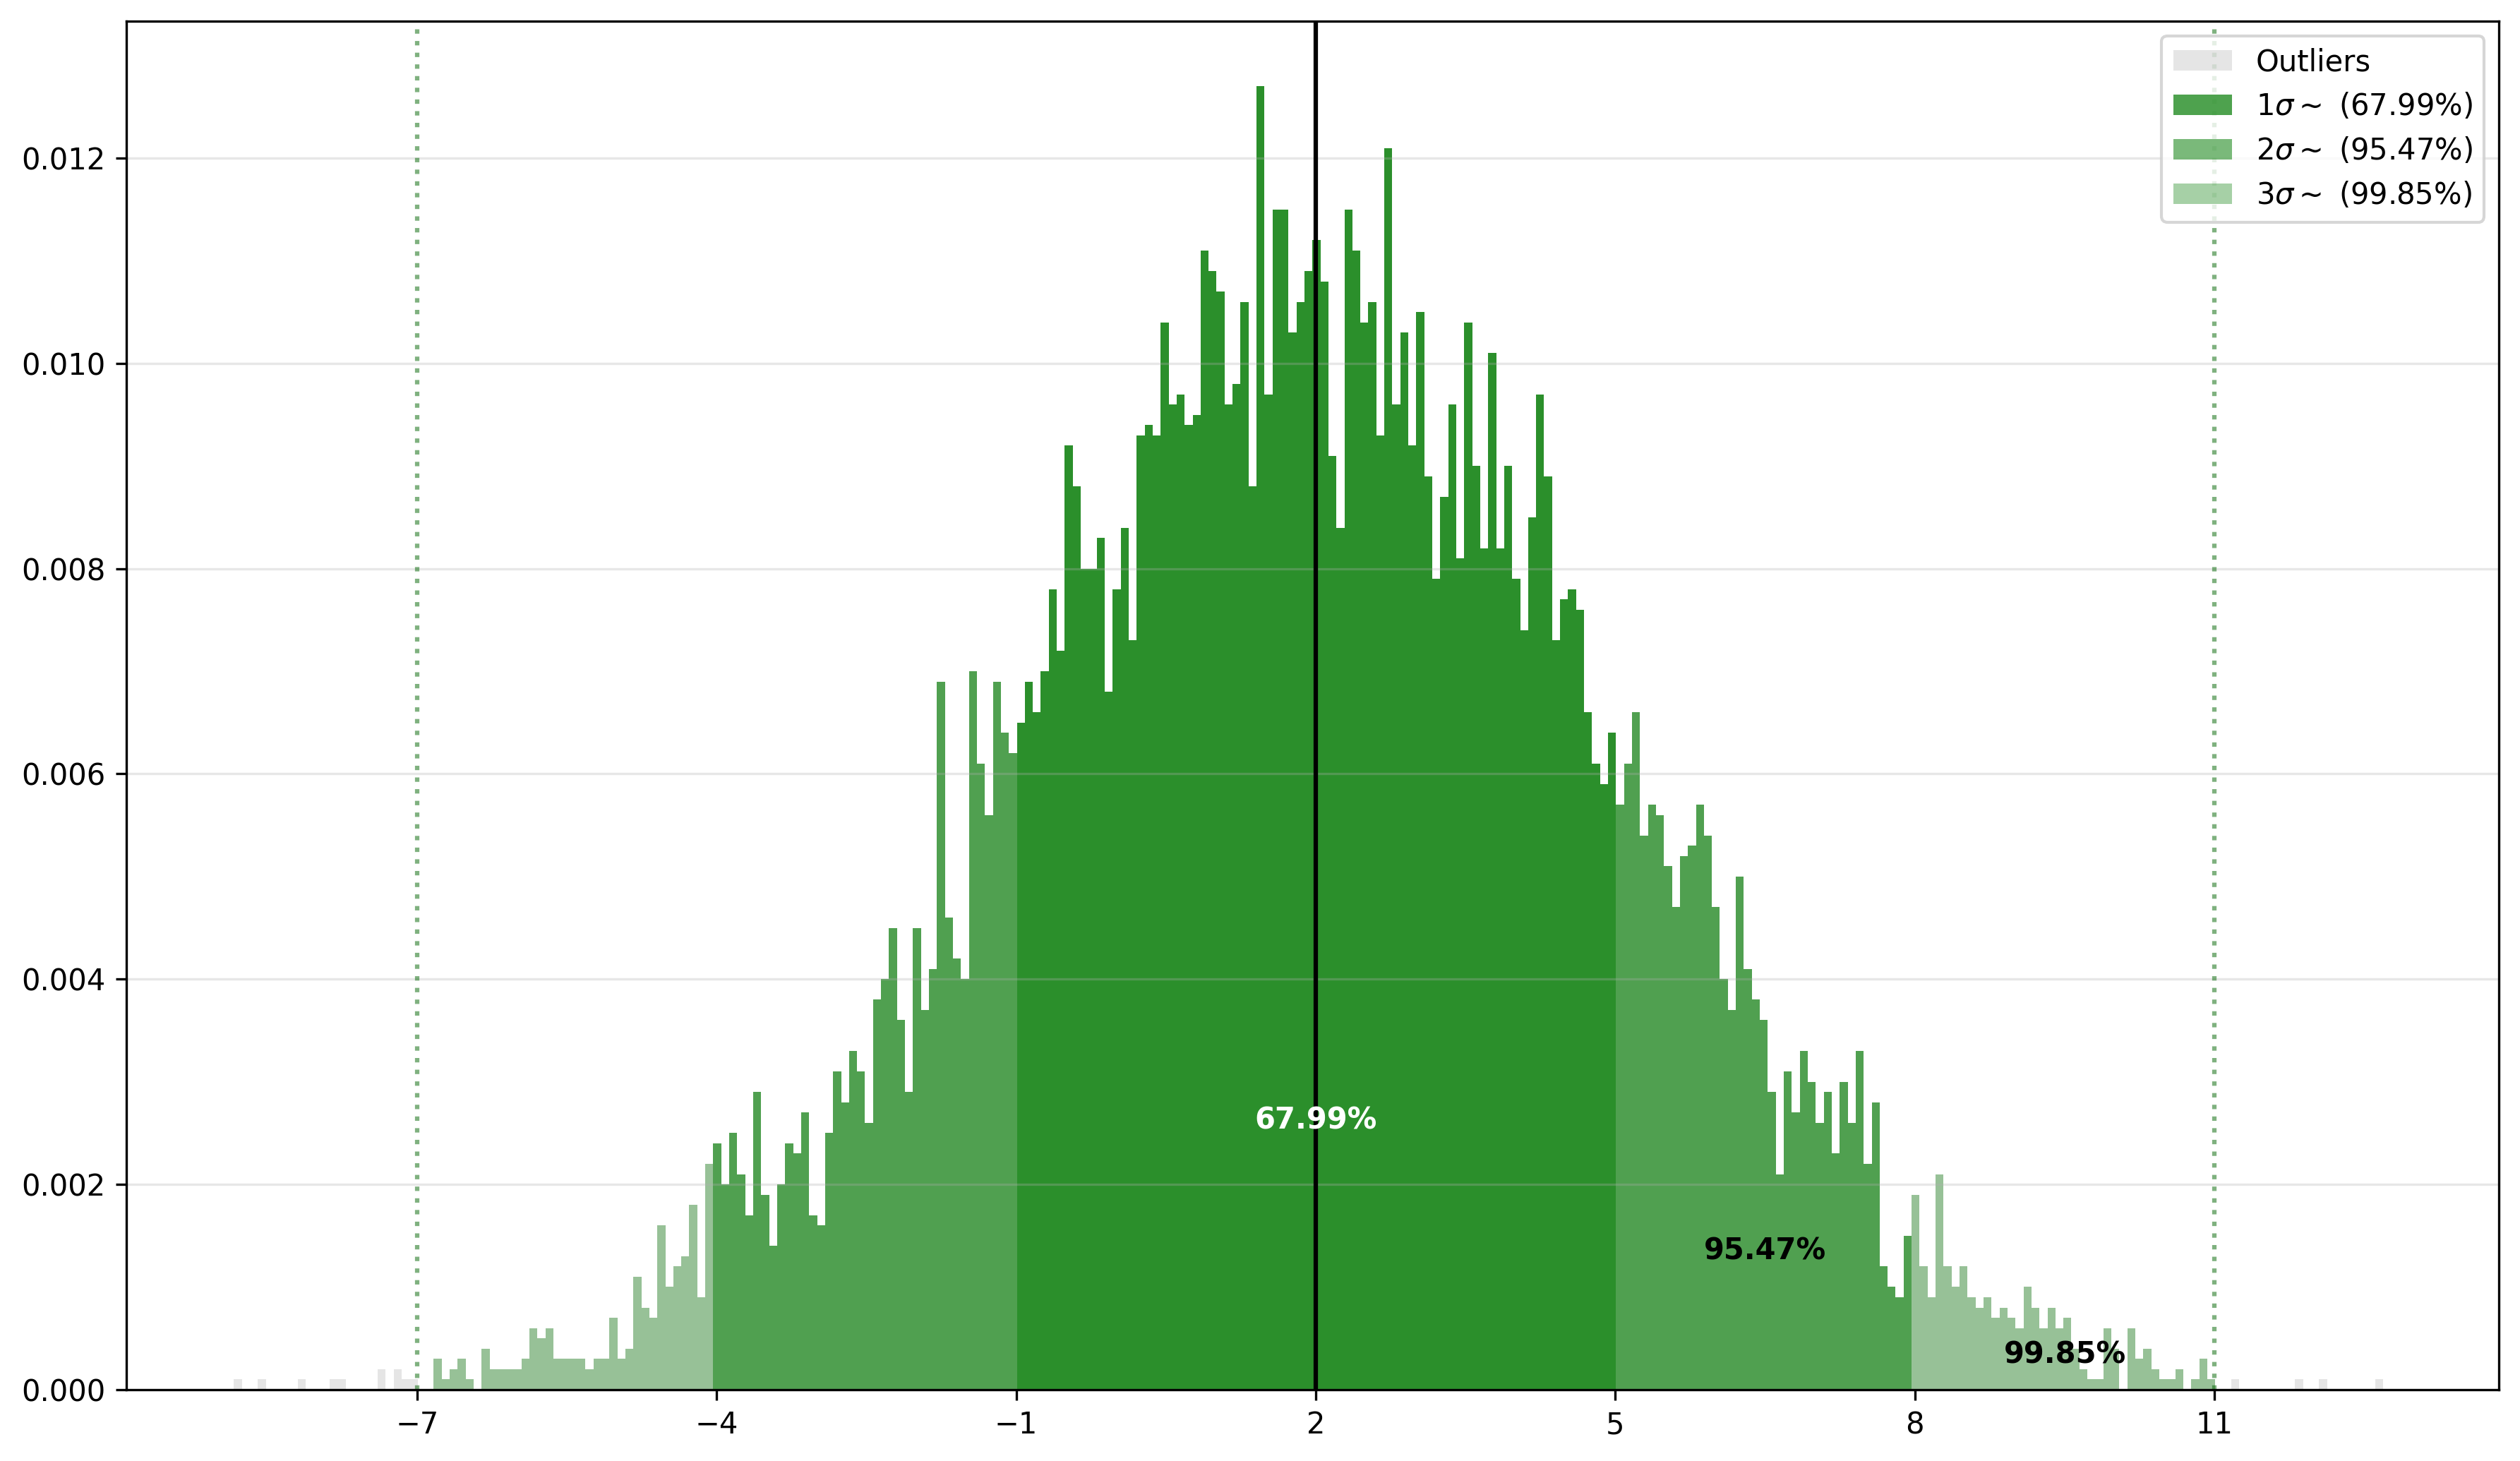

In [67]:
plot_hist_sig(2, 3, 0.8)
plot_hist_sig(2, 3, 0.08)

<BarContainer object of 36 artists>

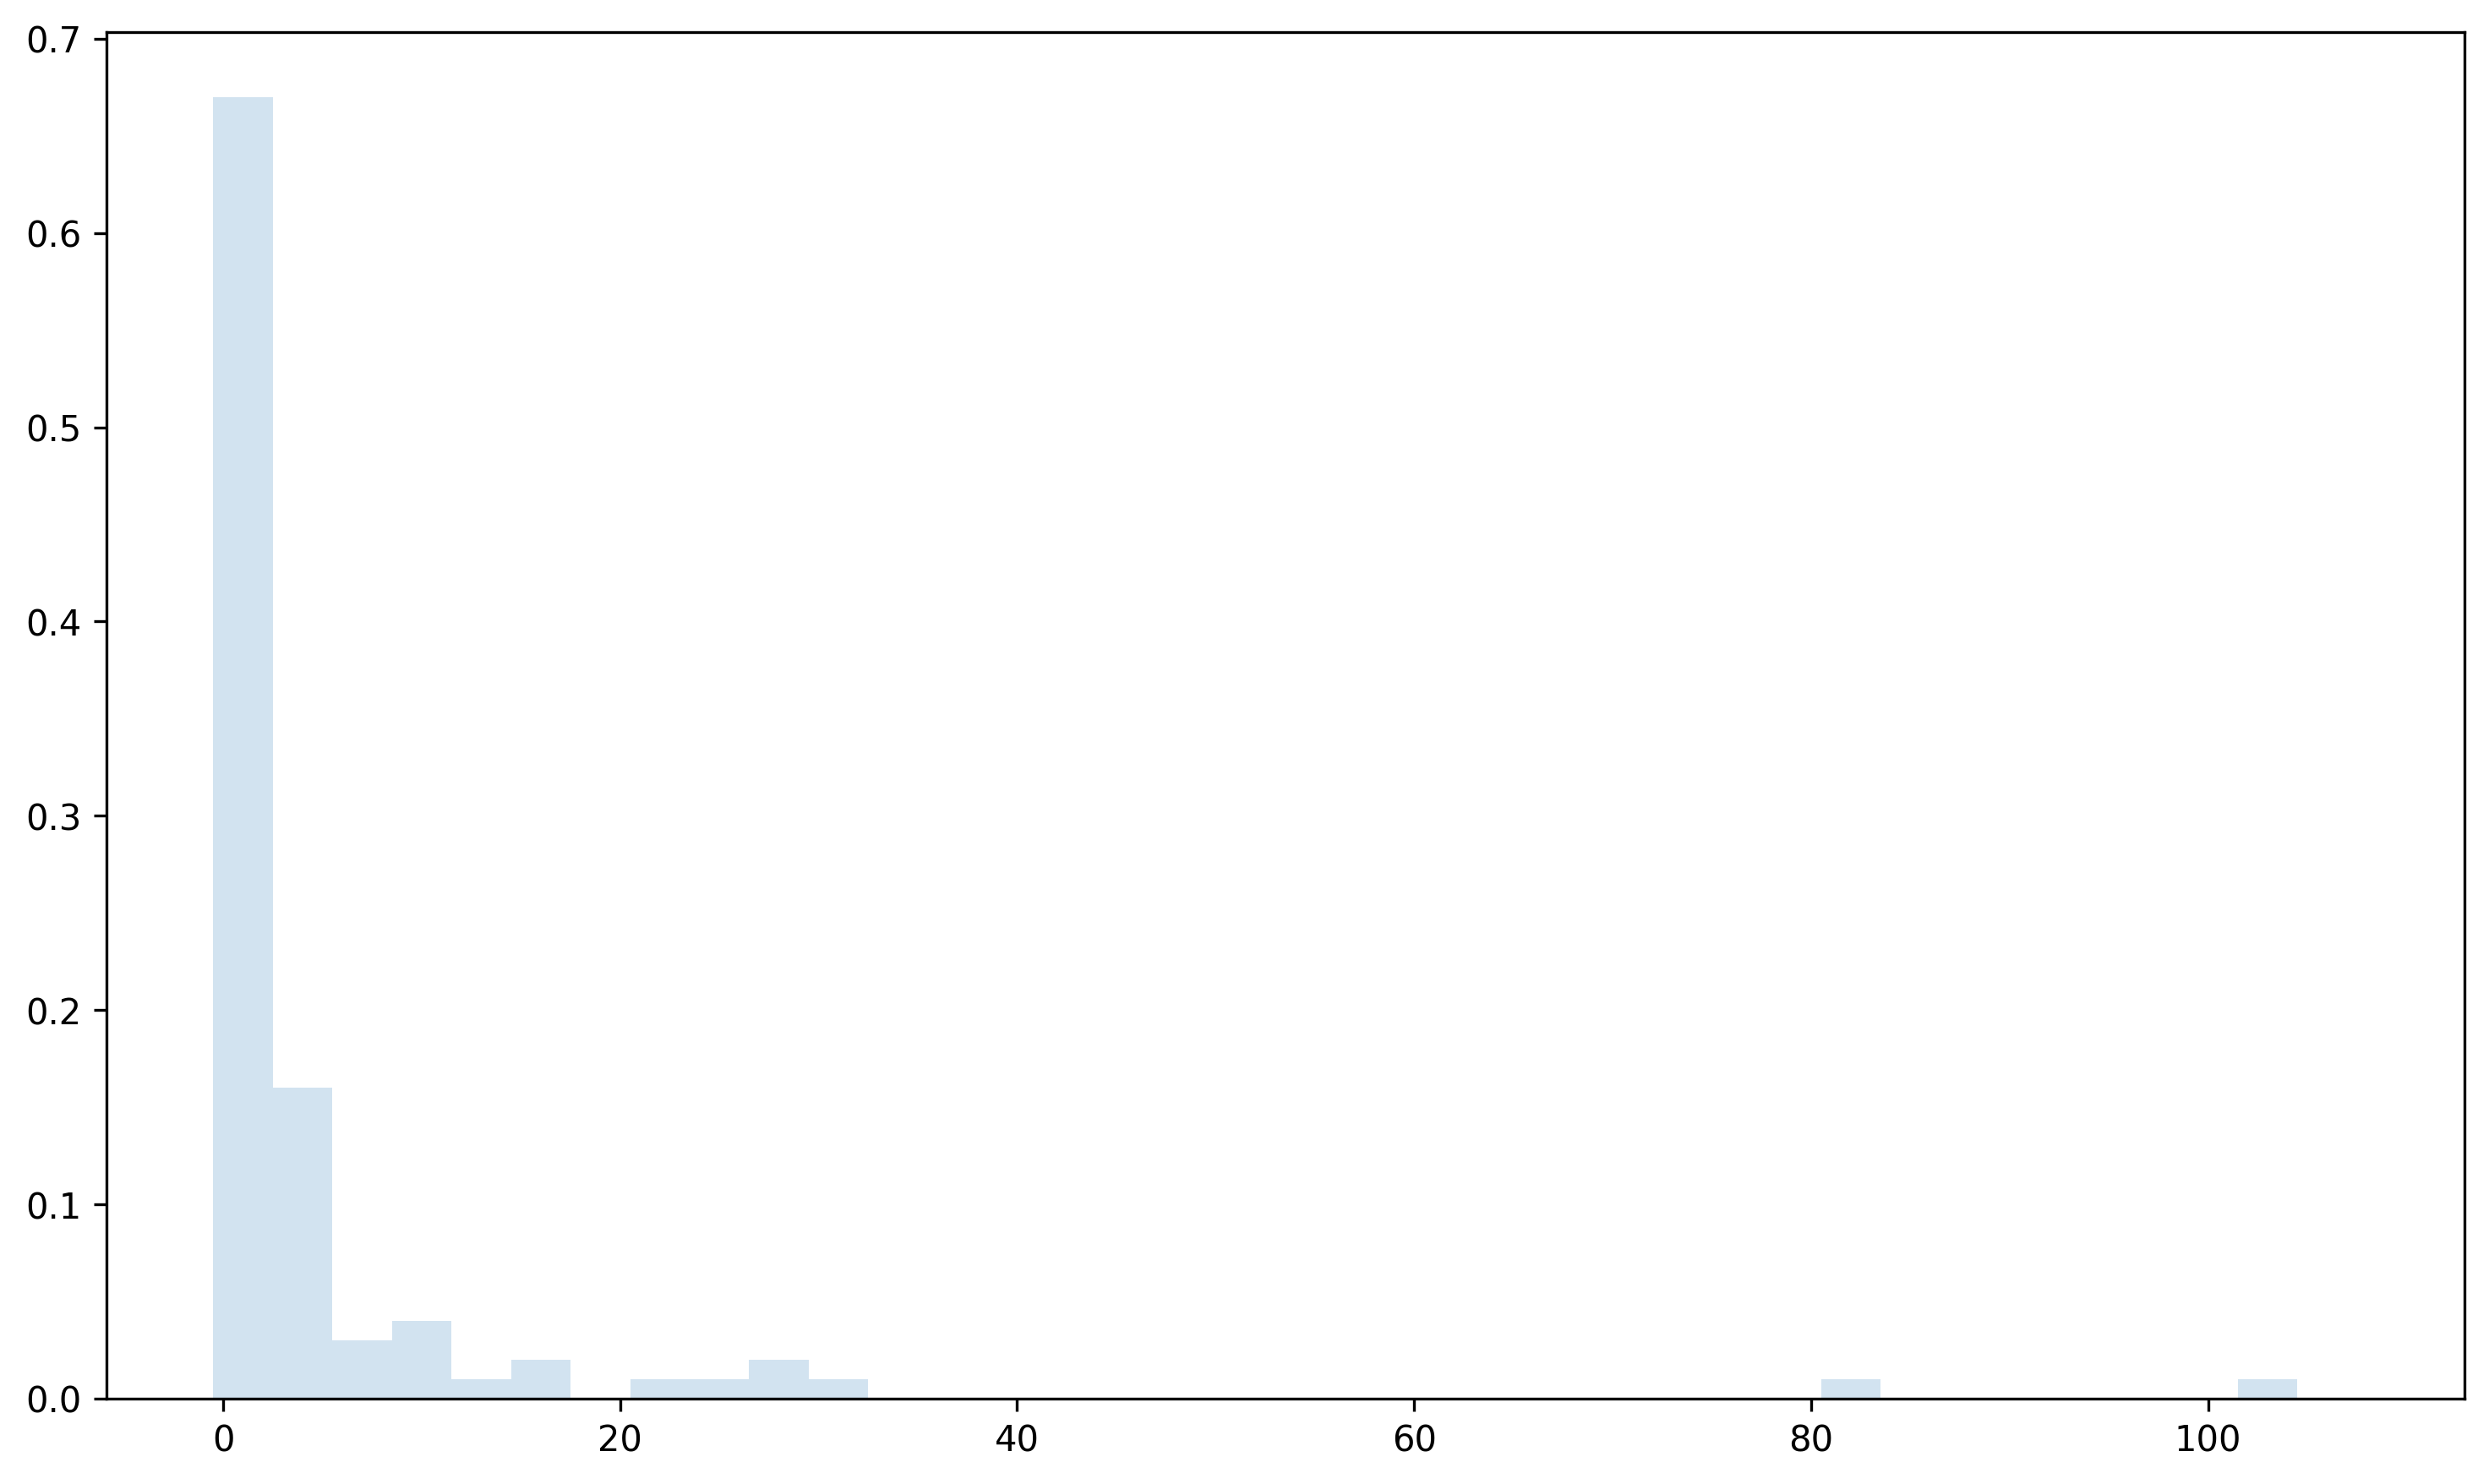

In [65]:

h = 3
res = hist(pdf(100), h)
centers = (res[0][:-1] + res[0][1:]) / 2

plt.figure(figsize=(12, 7))
plt.bar(centers, res[1], width=h, alpha=0.2)